# Travel Insurance Analysis

A tour & travel company piloted a Travel Insurance offer (with COVID cover) to ~2,000 past customers in 2019. 

The current notebook turns raw customer records into insights and a deployable classifier that ranks customers by purchase propensity.


## Index

- [Data preparation](#data-preparation)
- [Exploratory Data Analysis (EDA)](#eda)
- [Statistical inference](#stat-inference)
- [Modeling](#modeling)
- [Conclusions](#conclusions)

<a id="data-intake"></a>
## Data preparation

In [5]:
from statsmodels.stats.proportion import proportions_ztest
from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.inspection import partial_dependence, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import os, sqlite3, warnings
import pandas as pd

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
)

warnings.filterwarnings("ignore")

raw_df = pd.read_csv("TravelInsurancePrediction.csv")
raw_df = raw_df.drop(columns=["Unnamed: 0"])

display(raw_df.head(3))

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,400000,6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1


The Dataset is being prepared for the following analysis by editing the format of the columns:
- data are being separated into categorical and numerical
- Income data is formatted by removing commas
- New dummies columns are added where the categorical data are translated into 1 or 0

SQL is being used to manipulate the data, performing the conversion of categorical variables to numerical

In [ ]:
# Load data into an in-memory SQLite DB
conn = sqlite3.connect(":memory:")
raw_df.to_sql("raw", conn, index=False, if_exists="replace")

# Which categorical columns do we want to binarize (if present)?
binary_candidates = [
    "TravelInsurance",
    "FrequentFlyer",
    "EverTravelledAbroad",
    "ChronicDiseases",
    "GraduateOrNot",
    "Female",
    "Male",
    "Gender",  # will map Female→1, Male→0
]
all_cols = pd.read_sql_query("PRAGMA table_info(raw)", conn)["name"].tolist()
present = [c for c in binary_candidates if c in all_cols]


def q(c):
    return f"[{c}]"


# 3) Build a simple SELECT that keeps all original columns
#    and adds *_bin columns for the categorical ones
select_items = [q(c) for c in all_cols]

for c in present:
    if c == "Gender":
        select_items.append(
            f"""
            CASE
              WHEN lower(trim(CAST({q(c)} AS TEXT))) IN ('female','f') THEN 1
              WHEN lower(trim(CAST({q(c)} AS TEXT))) IN ('male','m')   THEN 0
              WHEN lower(trim(CAST({q(c)} AS TEXT)))='1' THEN 1
              WHEN lower(trim(CAST({q(c)} AS TEXT)))='0' THEN 0
              ELSE NULL
            END AS {q(c + '_bin')}
            """
        )
    else:
        select_items.append(
            f"""
            CASE
              WHEN lower(trim(CAST({q(c)} AS TEXT))) IN ('1','yes','y','true','t') THEN 1
              WHEN lower(trim(CAST({q(c)} AS TEXT))) IN ('0','no','n','false','f')  THEN 0
              ELSE NULL
            END AS {q(c + '_bin')}
            """
        )

sql = "CREATE TABLE ti_clean AS SELECT " + ", ".join(select_items) + " FROM raw"

with conn:
    conn.execute("DROP TABLE IF EXISTS ti_clean")
    conn.execute(sql)

# 4) Quick check
print(pd.read_sql_query("PRAGMA table_info(ti_clean)", conn)[["name", "type"]])
display(pd.read_sql_query("SELECT * FROM ti_clean LIMIT 5", conn))

                       name  type
0                       Age   INT
1           Employment Type  TEXT
2             GraduateOrNot  TEXT
3              AnnualIncome   INT
4             FamilyMembers   INT
5           ChronicDiseases   INT
6             FrequentFlyer  TEXT
7       EverTravelledAbroad  TEXT
8           TravelInsurance   INT
9       TravelInsurance_bin      
10        FrequentFlyer_bin      
11  EverTravelledAbroad_bin      
12      ChronicDiseases_bin      
13        GraduateOrNot_bin      


,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance,TravelInsurance_bin,FrequentFlyer_bin,EverTravelledAbroad_bin,ChronicDiseases_bin,GraduateOrNot_bin
0,31,Government Sector,Yes,400000,6,1,No,No,0,0,0,0,1,1
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0,0,0,0,0,1
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1,1,0,0,1,1
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0,0,0,0,1,1
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0,0,1,0,1,1


The following block ensures to  have a clean binary target before modeling.

- Pull the cleaned SQL table ti_clean into a pandas DataFrame.

- Pick the target (prefer binary):

- If TravelInsurance_bin exists, use it, otherwise, try to convert TravelInsurance to numeric with errors='coerce' and verify all non-NaN values are in {0,1}

- If valid, use it as the target, if neither a clean _bin column nor a valid numeric TravelInsurance is found, raise an error to stop the pipeline early.

In [26]:
df = pd.read_sql_query("SELECT * FROM ti_clean", conn)

target_col = None
if "TravelInsurance_bin" in df.columns:  # prefer the binay version previously created
    target_col = "TravelInsurance_bin"
elif (
    "TravelInsurance" in df.columns
):  # try to coerce the original column to numeric if possible
    tmp = pd.to_numeric(
        df["TravelInsurance"], errors="coerce"
    )  # errors="coerce" tells converters to turn invalid parses into missing values
    if set(np.unique(tmp.dropna())) <= {
        0,
        1,
    }:  # subset test: returns True iff every unique value is in {0, 1}.
        df["TravelInsurance"] = tmp.astype(float)
        target_col = "TravelInsurance"

if target_col is None:
    raise ValueError("No usable TravelInsurance target found.")

print("Target:", target_col, "| Shape:", df.shape)
display(df.head(3))

Target: TravelInsurance_bin | Shape: (1987, 14)


,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance,TravelInsurance_bin,FrequentFlyer_bin,EverTravelledAbroad_bin,ChronicDiseases_bin,GraduateOrNot_bin
0,31,Government Sector,Yes,400000,6,1,No,No,0,0,0,0,1,1
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0,0,0,0,0,1
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1,1,0,0,1,1


<a id="eda"></a>
## Exploratory Data Analysis (EDA)

First the dataset is reviewed to identify any missing and duplicate value, and the target column is reviewed to spot any Nan value.
The results are visualised before taking an action and removing the rows containing either duplicates or NaN values.

In [27]:
print("Dtypes:\n", df.dtypes)
na_counts = df.isna().sum().sort_values(ascending=False)  # count na values per column
print("\nMissing values per column:")
display(na_counts.to_frame("missing"))
df = df[df[target_col].notna()]

dup_count = df.duplicated().sum()  # count duplicate rows
print("Duplicate rows:", dup_count)
df.drop_duplicates(inplace=True)

X = df.drop(columns=[target_col])
numeric_cols = X.select_dtypes(
    include="number"
).columns.tolist()  # count numeric columns
categorical_cols = X.select_dtypes(
    exclude="number"
).columns.tolist()  # count non-numeric columns

print("\nNumeric:", numeric_cols)
print("Categorical:", categorical_cols)

print("\nSummary (numeric):")
display(df[numeric_cols].describe().T)

print("\nTarget distribution:")
display(df[target_col].value_counts(dropna=False))
display(df[target_col].value_counts(normalize=True, dropna=False))

Dtypes:
 Age                         int64
Employment Type            object
GraduateOrNot              object
AnnualIncome                int64
FamilyMembers               int64
ChronicDiseases             int64
FrequentFlyer              object
EverTravelledAbroad        object
TravelInsurance             int64
TravelInsurance_bin         int64
FrequentFlyer_bin           int64
EverTravelledAbroad_bin     int64
ChronicDiseases_bin         int64
GraduateOrNot_bin           int64
dtype: object

Missing values per column:


,missing
Age,0
Employment Type,0
GraduateOrNot,0
AnnualIncome,0
FamilyMembers,0
ChronicDiseases,0
FrequentFlyer,0
EverTravelledAbroad,0
TravelInsurance,0
TravelInsurance_bin,0


Duplicate rows: 738

Numeric: ['Age', 'AnnualIncome', 'FamilyMembers', 'ChronicDiseases', 'TravelInsurance', 'FrequentFlyer_bin', 'EverTravelledAbroad_bin', 'ChronicDiseases_bin', 'GraduateOrNot_bin']
Categorical: ['Employment Type', 'GraduateOrNot', 'FrequentFlyer', 'EverTravelledAbroad']

Summary (numeric):


,count,mean,std,min,25%,50%,75%,max
Age,1249.0,29.755805,2.921039,25.0,28.0,29.0,32.0,35.0
AnnualIncome,1249.0,934547.638110,360729.284255,300000.0,600000.0,900000.0,1200000.0,1800000.0
FamilyMembers,1249.0,4.890312,1.762313,2.0,4.0,5.0,6.0,9.0
ChronicDiseases,1249.0,0.333066,0.471499,0.0,0.0,0.0,1.0,1.0
TravelInsurance,1249.0,0.386709,0.487191,0.0,0.0,0.0,1.0,1.0
FrequentFlyer_bin,1249.0,0.236189,0.424910,0.0,0.0,0.0,0.0,1.0
EverTravelledAbroad_bin,1249.0,0.195356,0.396634,0.0,0.0,0.0,0.0,1.0
ChronicDiseases_bin,1249.0,0.333066,0.471499,0.0,0.0,0.0,1.0,1.0
GraduateOrNot_bin,1249.0,0.838271,0.368350,0.0,1.0,1.0,1.0,1.0



Target distribution:


TravelInsurance_bin
0    766
1    483
Name: count, dtype: int64

TravelInsurance_bin
0    0.613291
1    0.386709
Name: proportion, dtype: float64

### Plots

Data are visualised as per their distribution and with boxplot/violin chart. By pairing both the plots, it is possible to have a clear overview on the data structure.

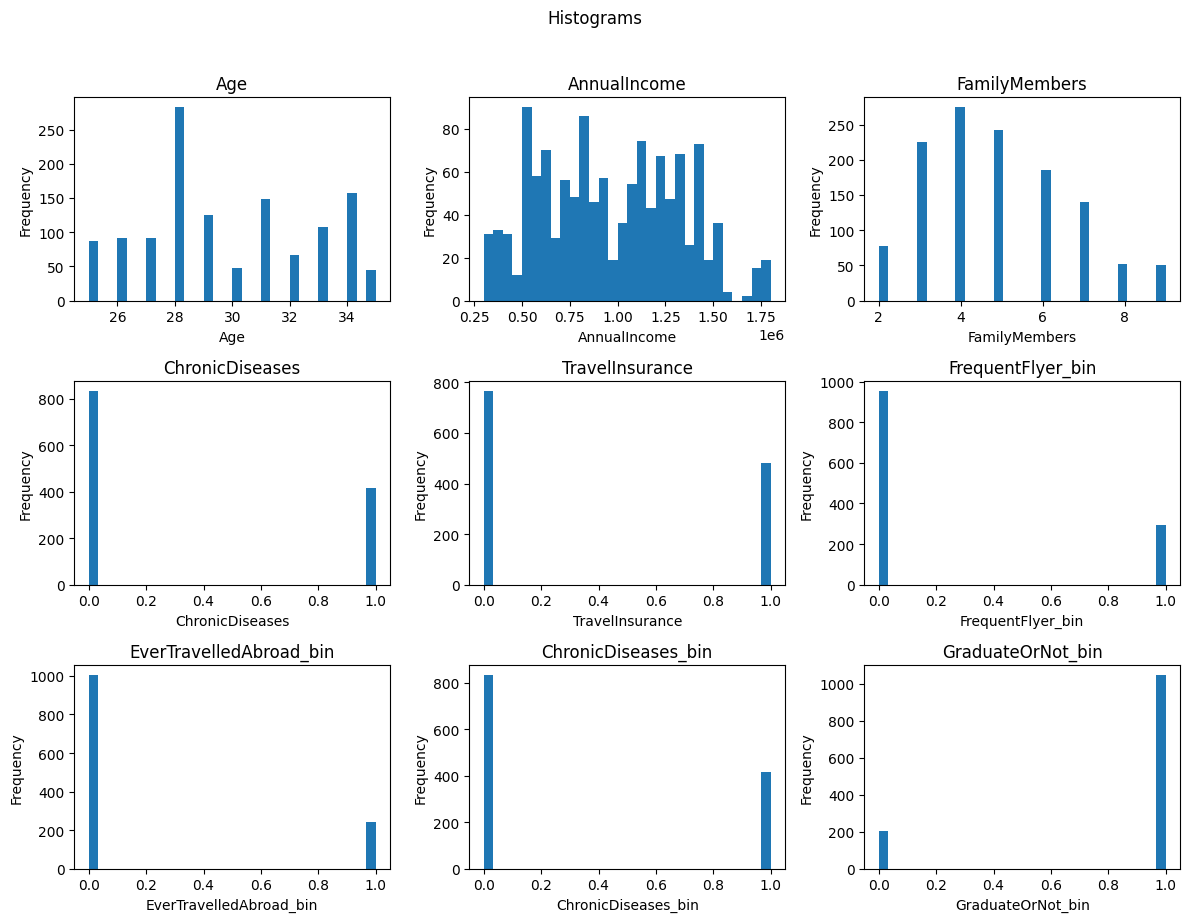

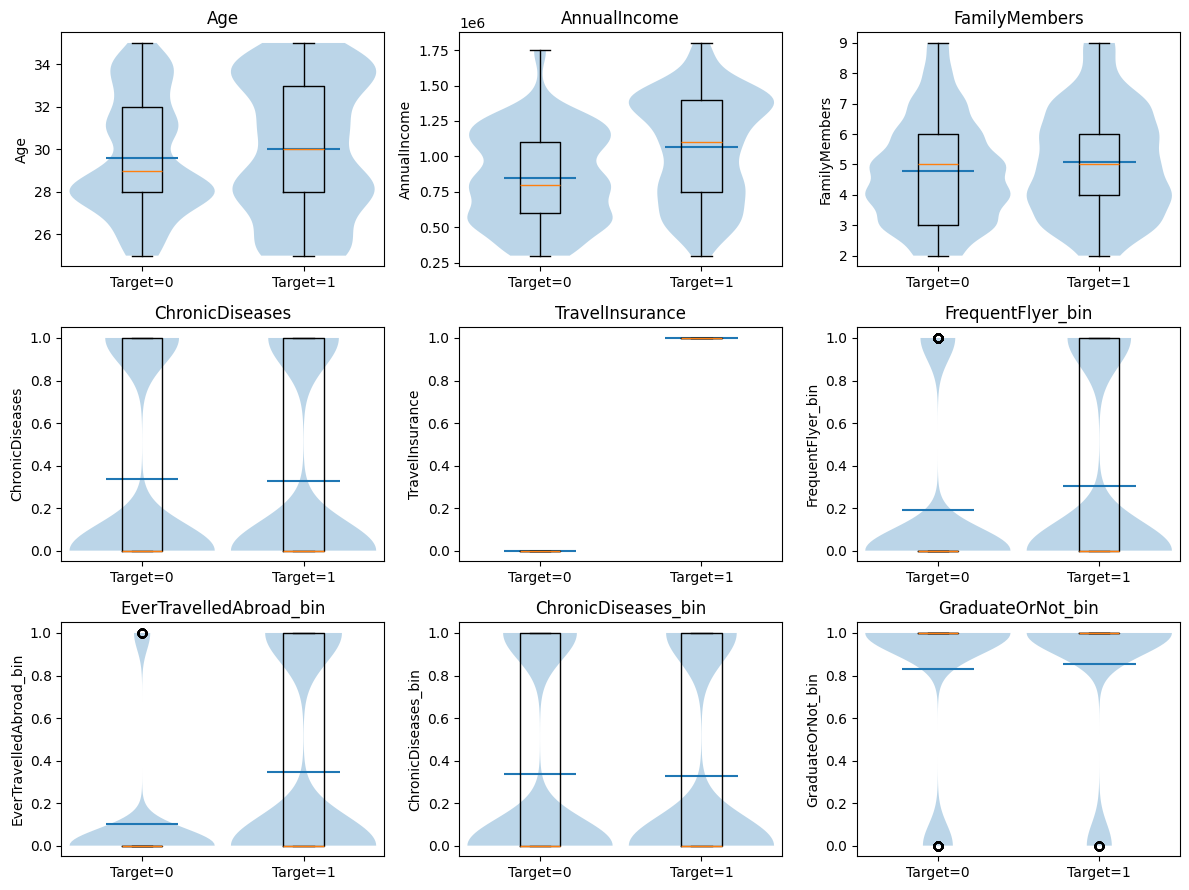

In [ ]:
# grid setup (no math module)
# grid size (change cols if you want a different layout)
cols = 3
rows = (len(numeric_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
axes = axes.ravel()

for i, c in enumerate(numeric_cols):  # Turns the list into (index, value) pairs.
    axes[i].hist(df[c].dropna(), bins=30)
    axes[i].set_title(c)
    axes[i].set_xlabel(c)
    axes[i].set_ylabel("Frequency")

fig.suptitle("Histograms", y=1.02)
fig.tight_layout()
plt.show()

# grid size (change cols if you want a different layout)
cols = 3
rows = (len(numeric_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
axes = axes.ravel()

for ax, col in zip(axes, numeric_cols):
    v0 = df.loc[df[target_col] == 0, col].dropna()
    v1 = df.loc[df[target_col] == 1, col].dropna()

    # violin = distribution shape
    ax.violinplot(
        [v0, v1], positions=[1, 2], widths=0.9, showmeans=True, showextrema=False
    )

    # box = robust summary (median/IQR)
    ax.boxplot([v0, v1], positions=[1, 2], widths=0.25)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Target=0", "Target=1"])
    ax.set_title(col)
    ax.set_ylabel(col)

# hide any unused subplots
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


fig2.suptitle(f"Boxplots by {target_col}", y=1.02)
fig2.tight_layout()
plt.show()

The above plots show some important features of the data:
- The Annual Income is rather evenly distribuited, whith peaks that are mirrored between the two sides of the plot
- We notice that the number of family members tend to be between 3 and 6
- The Age variable shows somes bias, especially for the aged 28, who appears more frequently
- Frequent Flyer variable is strongly categotical, more than EverTravelledAbroad and GraduateOrNot if we compare the confidence interval. This indicates a significant predicitve power over the TravelInsurance, while other categorical variables might be affected also by other features.

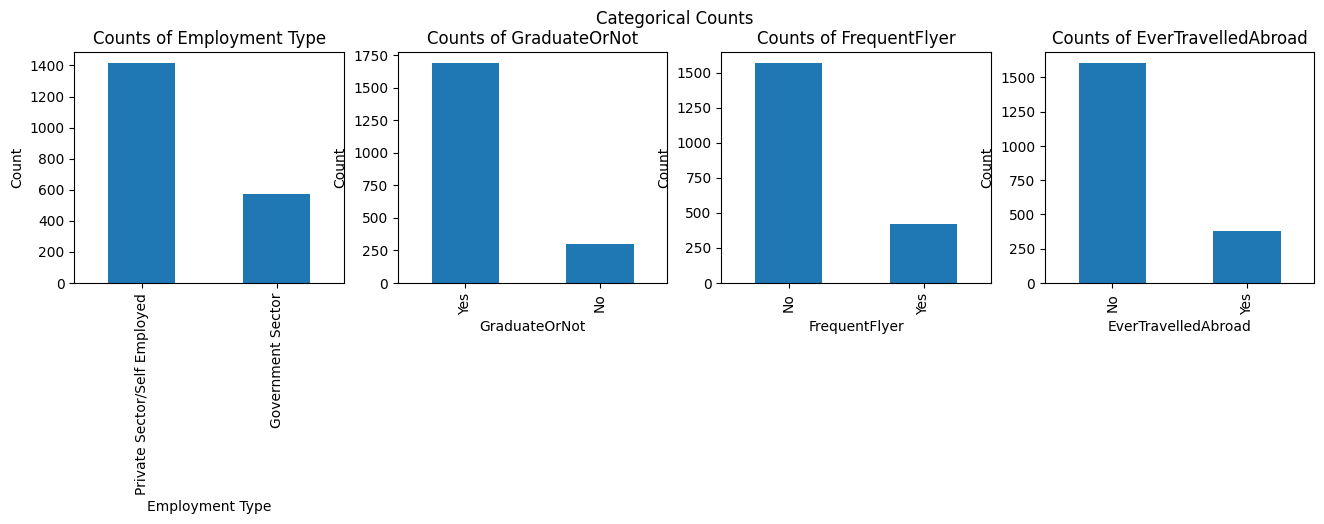

In [11]:
# layout (no math/numpy)
n = len(categorical_cols)
cols = 4  # change if you want more/less per row
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
# make axes a flat list regardless of shape
try:
    axes = axes.ravel()
except AttributeError:
    axes = [axes]

for i, c in enumerate(categorical_cols):
    q = f"SELECT [{c}] AS category, COUNT(*) AS n FROM ti_clean GROUP BY 1 ORDER BY 2 DESC"
    counts = pd.read_sql_query(q, conn)
    counts.set_index("category")["n"].plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"Counts of {c}")
    axes[i].set_xlabel(c)
    axes[i].set_ylabel("Count")

# hide any unused axes
for j in range(i + 1, rows * cols):
    axes[j].axis("off")

fig.suptitle("Categorical Counts", y=1.02)
fig.tight_layout()
plt.show()

It is insightful to review the latest plot as a significant part of the population is not a frequent flyer and never travlled abroad, that makes assume how most of them they allegedly not interested in a Travel Insurance.

### Correlations & Cramér's V

The analysis proceeds with the review of the correlation to spot possible patterns between all the variables.

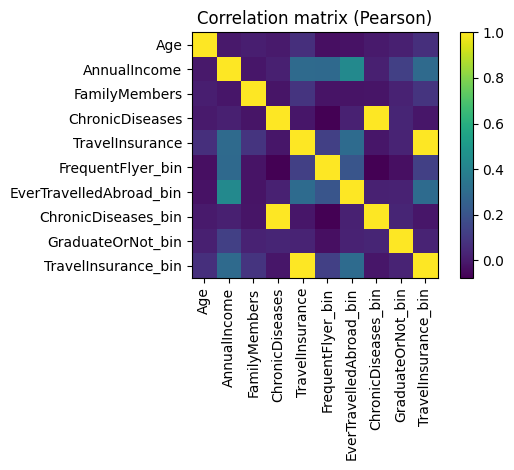

,categorical_feature,cramers_v
3,EverTravelledAbroad,0.297928
2,FrequentFlyer,0.122306
0,Employment Type,0.068954
1,GraduateOrNot,0.008440


In [ ]:
num_for_corr = [c for c in numeric_cols if c != target_col] + [target_col]
if len(num_for_corr) >= 2:
    corr = df[num_for_corr].corr(method="pearson")
    plt.figure()
    plt.imshow(corr, interpolation="nearest")
    plt.xticks(range(len(num_for_corr)), num_for_corr, rotation=90)
    plt.yticks(range(len(num_for_corr)), num_for_corr)
    plt.title("Correlation matrix (Pearson)")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


def cramers_v(confusion):
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.values.sum()
    r, k = confusion.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2corr / max((kcorr - 1), (rcorr - 1)))


if df[target_col].nunique() == 2:
    rows = []
    for c in categorical_cols:
        tbl = pd.crosstab(df[c], df[target_col])
        if tbl.shape[0] > 1 and tbl.shape[1] > 1:
            rows.append((c, cramers_v(tbl)))
    if rows:
        cr = pd.DataFrame(
            rows, columns=["categorical_feature", "cramers_v"]
        ).sort_values("cramers_v", ascending=False)
        display(cr)

The matrix results show no strong linear correlation between the features: this is understandable by the dark cells scattered all around the matrix. A ligher pattern can be seen in relation to the Annual Income, that suggest moderate linear signal.

The Cramer matrix also provide an insight about the correlation between the target variable and the categorical variables: in this case as well the value are really small, indicationg no particular effect

The detection of the outlier is made with the Interquartile range methode, considered more robust for skewed distributions.

In [ ]:
# Columns to check (only the ones that exist)
cols = [c for c in ["Age", "AnnualIncome", "FamilyMembers"] if c in df.columns]

iqr_out = {}

for c in cols:
    # clean to numeric and drop NA
    s = pd.to_numeric(df[c], errors="coerce").dropna()
    if len(s) < 5:
        continue

    # IQR bounds
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    # indices of rows outside the bounds
    mask = (pd.to_numeric(df[c], errors="coerce") < lo) | (
        pd.to_numeric(df[c], errors="coerce") > hi
    )
    iqr_out[c] = df.index[mask].tolist()

    print(f"{c}: {mask.sum()} outliers | bounds [{lo:.2f}, {hi:.2f}]")

# Optional: peek at the first few indices per column
for c, idx in iqr_out.items():
    print(f"{c} sample indices:", idx[:10])

Age: 0 outliers | bounds [22.00, 38.00]
AnnualIncome: 0 outliers | bounds [-300000.00, 2100000.00]
FamilyMembers: 0 outliers | bounds [1.00, 9.00]
Age sample indices: []
AnnualIncome sample indices: []
FamilyMembers sample indices: []


<a id="stat-inference"></a>
## Statistical inference

In the previous results we saw that the Annual Income and the Frequent Flyer are the variables worth-investigating, this as per said, due to a slight linear correlation of the first and a significant categorical power of the second. 

In addition, due to its imbalanced distribution, also the Age variable is being tested.

Based on this, the following hypothesis are stated:


1) **Annual Income vs. Travel Insurance**

Null hypothesis (H₀): The mean annual income is the same for people who did and did not purchase travel insurance.

Alternative hypothesis (H₁): The mean annual income differs between the two groups.

Annual income showed to have a significant linera correlation with the target variable, reason why its being tested.

2) **Frequent Flyer vs. Travel Insurance**

Null hypothesis (H₀): The proportion of people purchasing travel insurance is the same among frequent flyers and non-frequent flyers.

Alternative hypothesis (H₁): The proportions differ between frequent flyers and non-frequent flyers.

Frequent Flyer is the strongest categorical variable with an effective predictive power.

3) **Age vs. Travel Insurance**

Null hypothesis (H₀): The mean age is the same for people who did and did not purchase travel insurance.

Alternative hypothesis (H₁): The mean age differs between the two groups.

Age showed some bias in the distribution, mostly around the value 28, reason why this is being tested.



All the hypothesis are being tested with Welch and 95% confidence interval.

In [ ]:
alpha = 0.05
out_lines = []


def ci_mean(x, confidence=0.95):
    s = pd.Series(x, dtype=float).dropna()
    n = len(s)
    m = s.mean()
    se = s.std(ddof=1) / np.sqrt(max(n, 1))
    h = stats.t.ppf(0.5 + confidence / 2, max(n - 1, 1)) * se
    return (m - h, m + h, n, m)


def ci_prop(successes, n, confidence=0.95):
    if n == 0:
        return (np.nan, np.nan, 0, np.nan)
    z = stats.norm.ppf(0.5 + confidence / 2)
    ph = successes / n
    denom = 1 + (z * z) / n
    center = (ph + (z * z) / (2 * n)) / denom
    h = (z * np.sqrt(ph * (1 - ph) / n + (z * z) / (4 * n * n))) / denom
    return (center - h, center + h, n, ph)


def mean_diff_block(col_candidates, label_for_line=""):
    """Pick the first existing column, run Welch t-test + CIs by target, append lines."""
    for col in col_candidates:
        if col in df.columns:
            a = pd.to_numeric(
                df.loc[df[target_col] == 0, col], errors="coerce"
            ).dropna()
            b = pd.to_numeric(
                df.loc[df[target_col] == 1, col], errors="coerce"
            ).dropna()
            if len(a) > 2 and len(b) > 2:
                t, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
                ci0, ci1 = ci_mean(a), ci_mean(b)
                out_lines.append(
                    f"{col} mean (target=0) 95% CI: {ci0[0]:.2f}–{ci0[1]:.2f} (n={ci0[2]}, mean={ci0[3]:.2f})"
                )
                out_lines.append(
                    f"{col} mean (target=1) 95% CI: {ci1[0]:.2f}–{ci1[1]:.2f} (n={ci1[2]}, mean={ci1[3]:.2f})"
                )
                prefix = "Welch t-test" + (
                    f" {label_for_line}" if label_for_line else ""
                )
                out_lines.append(
                    f"{prefix}: t={t:.3f}, p={p:.4g}; decision @ α={alpha}: "
                    + ("Reject H0" if p < alpha else "Fail to reject H0")
                )
            break  # only use the first existing column


# AnnualIncome mean difference
mean_diff_block(["AnnualIncome_num", "AnnualIncome"])

# Two-proportion z-test: FrequentFlyer
try:
    from statsmodels.stats.proportion import proportions_ztest

    if "FrequentFlyer_bin" in df.columns:
        grp = (
            df.groupby("FrequentFlyer_bin")[target_col]
            .agg(["sum", "count"])
            .reindex([0, 1])
        )
        if grp["count"].min() > 0 and grp.shape[0] == 2:
            stat, p = proportions_ztest(
                count=grp["sum"].values, nobs=grp["count"].values
            )
            ci0 = ci_prop(int(grp.loc[0, "sum"]), int(grp.loc[0, "count"]))
            ci1 = ci_prop(int(grp.loc[1, "sum"]), int(grp.loc[1, "count"]))
            out_lines.append(
                f"TravelInsurance proportion (FF=0) 95% CI: {ci0[0]:.3f}–{ci0[1]:.3f} (n={ci0[2]}, p̂={ci0[3]:.3f})"
            )
            out_lines.append(
                f"TravelInsurance proportion (FF=1) 95% CI: {ci1[0]:.3f}–{ci1[1]:.3f} (n={ci1[2]}, p̂={ci1[3]:.3f})"
            )
            out_lines.append(
                f"Two-proportion z-test (FF vs non-FF): z={stat:.3f}, p={p:.4g}; decision @ α={alpha}: "
                + ("Reject H0" if p < alpha else "Fail to reject H0")
            )
except Exception:
    out_lines.append("Two-proportion z-test not available (statsmodels missing).")

#  Age mean difference
mean_diff_block(["Age_num", "Age"], label_for_line="(age)")

#  Overall take-up CI
succ = int(pd.to_numeric(df[target_col], errors="coerce").sum())
nobs = int(pd.to_numeric(df[target_col], errors="coerce").count())
ci = ci_prop(succ, nobs)
out_lines.append(
    f"Overall take-up 95% CI: {ci[0]:.3f}–{ci[1]:.3f} (n={ci[2]}, p̂={ci[3]:.3f})"
)

print("\n".join(out_lines))

AnnualIncome mean (target=0) 95% CI: 827296.14–873487.15 (n=766, mean=850391.64)
AnnualIncome mean (target=1) 95% CI: 1034614.78–1101410.07 (n=483, mean=1068012.42)
Welch t-test: t=-10.527, p=1.498e-24; decision @ α=0.05: Reject H0
TravelInsurance proportion (FF=0) 95% CI: 0.323–0.383 (n=954, p̂=0.352)
TravelInsurance proportion (FF=1) 95% CI: 0.442–0.555 (n=295, p̂=0.498)
Two-proportion z-test (FF vs non-FF): z=-4.503, p=6.688e-06; decision @ α=0.05: Reject H0
Age mean (target=0) 95% CI: 29.41–29.79 (n=766, mean=29.60)
Age mean (target=1) 95% CI: 29.72–30.29 (n=483, mean=30.00)
Welch t-test (age): t=-2.305, p=0.0214; decision @ α=0.05: Reject H0
Overall take-up 95% CI: 0.360–0.414 (n=1249, p̂=0.387)



The ultimate outcomes are the following:

Income: Strong evidence that higher income individuals are more likely to purchase travel insurance.

Frequent Flyer status: Very strong predictor—frequent flyers have nearly double the take-up rate.

Age: Statistically significant but only a slight increase in mean age among purchasers, so limited practical impact.

The general trend is that travel insurance purchase correlates most with financial capacity (income) and travel habits (flying frequency), not so much with age.

<a id="Modeling"></a>
## Modeling

It follows the model creation, using clasification logarithm as the logistic regression and the Random Forest

In [35]:
df_model = df.dropna(subset=[target_col]).copy()
exclude = {target_col, "TravelInsurance"}
X = df_model[[c for c in df_model.columns if c not in exclude]]
y = df_model[target_col].astype(int)

num_feats = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
cat_feats = [c for c in X.columns if c not in num_feats]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(with_mean=False),
            num_feats,
        ),  # scales each numeric column by its standard deviation
        # (Gradient-based models (linear/logistic regression, neural nets) converge more reliably when features are similarly scaled)
        # Distance-based models: k-NN, k-means, SVM (especially with RBF) rely on distances; scaling prevents one feature from dominating.
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            cat_feats,
        ),  # turns categorical columns into one-hot/dummy columns
    ],
    remainder="drop",
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

During the modelling a Pipeline has been used: this is a single object that chains together the preprocessing steps and the final estimator. 
The preprocessors are the transformers that take the raw features X and learn how to clean/convert them on the training data, then apply the same transformation to any future data. Example for the preprocessors are the imputers, scalers and encoders. All the learned pieces like medians and means/stds are stored inside the pipeline.
The final estimator is literally the predictive model that takes the alread-transformed features and learns to predict the target values. In the current case the Logistic Regression and the Random Forest Classifier represent the final estimator.

In [36]:
models = {}

# Logistic Regression

pipe_lr = Pipeline(
    [("prep", preprocess), ("clf", LogisticRegression(max_iter=1000, solver="lbfgs"))]
)

With GridSearchCV, an hyperparameter search is done. These are set before training and control how the learning happens or how complex the model can become (e.g., regularization strength, tree depth, learning rate). 
It is crucial to look for them to avoid any overfit or undefit of the model, and tuning aims to maximize the performance on unseen data.
The tuning is really important not only for comparing two models, but also in more complex models, like deep neural nets.

In [ ]:
grid_lr = {"clf__C": [0.1, 1.0, 10.0], "clf__penalty": ["l2"]}
gs_lr = GridSearchCV(
    pipe_lr, grid_lr, cv=5, scoring="roc_auc"
)  # grid_lr represents the hyperparameter space to search over
gs_lr.fit(X_train, y_train)
models["LogReg"] = gs_lr

In [39]:
# Random Forest
pipe_rf = Pipeline(
    [("prep", preprocess), ("clf", RandomForestClassifier(random_state=42))]
)
grid_rf = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [None, 8, 16],
    "clf__min_samples_split": [2, 5],
}
gs_rf = GridSearchCV(pipe_rf, grid_rf, cv=5, scoring="roc_auc")
gs_rf.fit(X_train, y_train)
models["RF"] = gs_rf

The gradient boosting is an ensemble technique that builds a strong predictor by adding many small, weak models (usually shallow decision trees) sequentially.
Each new tree is trained to correct the mistakes (the negative gradient of the loss) made by the current ensemble.

To evaluate the results we use the Cross-validation. This tecnique repeatedly split the training data into folds, train on some folds, validate on the held-out fold, and average the metric.
The pros to use it are various:

- More reliable performance estimate than a single train/validation split.

- Detects overfitting (model does well on some folds, poorly on others).

- Model/parameter selection: compare algorithms and tune hyperparameters using the same protocol.

- Data efficiency: every sample is used for both training and validation (at different times).

In [ ]:
# Gradient Boosting

pipe_gb = Pipeline(
    [("prep", preprocess), ("clf", GradientBoostingClassifier(random_state=42))]
)
grid_gb = {
    "clf__n_estimators": [150, 300],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [2, 3],
}
gs_gb = GridSearchCV(pipe_gb, grid_gb, cv=5, scoring="roc_auc")
gs_gb.fit(X_train, y_train)
models["GB"] = gs_gb

cv_results = pd.DataFrame(
    [
        {"model": k, "cv_roc_auc": v.best_score_, "best_params": v.best_params_}
        for k, v in models.items()
    ]
).sort_values("cv_roc_auc", ascending=False)
print("Cross-validated ROC AUC:")
display(cv_results)

Cross-validated ROC AUC:


,model,cv_roc_auc,best_params
2,GB,0.736440,"{'clf__learning_rate': 0.05, 'clf__max_depth':..."
1,RF,0.704213,"{'clf__max_depth': 8, 'clf__min_samples_split'..."
0,LogReg,0.701349,"{'clf__C': 1.0, 'clf__penalty': 'l2'}"


The meaning of the ROC-AUC is found in the quality of the prediction. 
Since the gradient Boosting (GB) method performs the best with a ROC-AUC value of 0.736, this means that ff we pick a random buyer (positive) and a random non-buyer (negative), there’s a 73.6% chance the model gives the buyer a higher score as GB will capture non-linearities/interactions better than the linear baseline


In [ ]:
def evaluate(name, est, X_test, y_test):
    if hasattr(est, "predict_proba"):
        proba = est.predict_proba(
            X_test
        )[  # predict_proba(X) returns an array of shape (n_samples, n_classes).
            :, 1
        ]
    else:
        proba = est.decision_function(X_test)  # Otherwise, use a decision score:
    pred = (proba >= 0).astype(
        int
    )  # decision_function returns a real-valued score (margin/logit). Larger ⇒ “more positive,” smaller ⇒ “more negative.” These are not probabilities.
    return {
        "model": name,
        "test_roc_auc": roc_auc_score(y_test, proba),
        "test_accuracy": accuracy_score(y_test, pred),
        "test_f1": f1_score(y_test, pred),
        "test_precision": precision_score(y_test, pred),
        "test_recall": recall_score(y_test, pred),
        "test_avg_precision": average_precision_score(y_test, proba),
    }


test_rows = []
for name, gs in models.items():
    test_rows.append(evaluate(name, gs.best_estimator_, X_test, y_test))
test_df = pd.DataFrame(test_rows).sort_values("test_roc_auc", ascending=False)
print("Test-set metrics:")
display(test_df)

best_name = test_df.iloc[0]["model"]
best_est = models[best_name].best_estimator_
print("Best base model:", best_name)

Test-set metrics:


,model,test_roc_auc,test_accuracy,test_f1,test_precision,test_recall,test_avg_precision
2,GB,0.686241,0.388,0.559078,0.388,1.0,0.638179
1,RF,0.676875,0.388,0.559078,0.388,1.0,0.615739
0,LogReg,0.645138,0.388,0.559078,0.388,1.0,0.552823


Best base model: GB


The results lead to the following conclusion:
- AUC/AP show a certain ranking quality GB > RF > LogReg

### ROC and PR curves

ROC and PR curves both show how a scored classifier behaves as the decision threshold varies —but they emphasize different trade-offs.
ROC and PR are both threshold curves built from the model’s scores (probabilities or decision values) and they show what happens as the decision threshold is moved from “super strict” to “super lenient.” The probabilistic meaning shows the chance that a randomly chosen positive case gets a higher score than a randomly chosen negative.

The building of these curves is based on three steps:
- Compute a score for every example (higher = more likely positive).
- Compute a score for every example (higher = more likely positive).
- Sort by score and sweep a threshold from high → low.

The way the results are showed change as follows:
- ROC curve
  - y-axis: TP / (TP+FN) (Recall)
  - x-axis: FPR = FP / (FP+TN) 
- PR curve
  - x-axis: TP / (TP+FN) (Recall - how many predicted 1 are actual 1 ?)
  - y-axis: TP / (TP+FP) (Precision - how many actual 1 were predicted ?)

An interpretation can be as follow:
A ROC point (FPR=0.10, TPR=0.80) means: at this threshold you catch 80% of positives while 10% of negatives are wrongly flagged.
A PR point (Recall=0.80, Precision=0.25) means: you find 80% of positives, but only 25% of your alerts are correct (75% false alarms).

Also, considering that the AUC is the area under the curve,  AUC = 0.79 ≈ “in 79% of random positive–negative pairs, the model ranks the positive higher.”


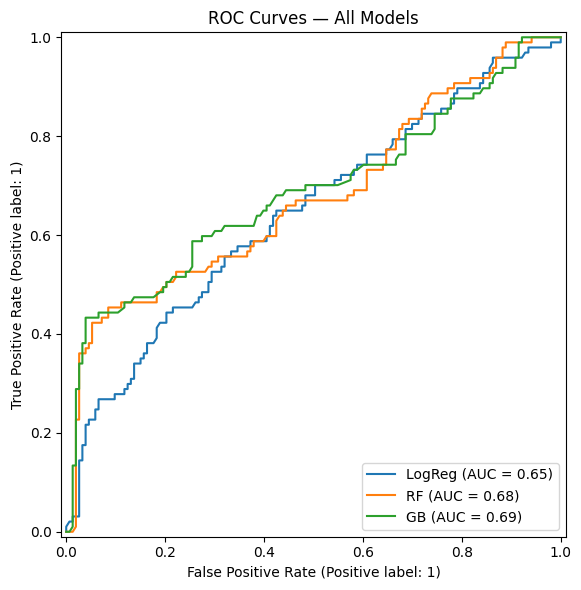

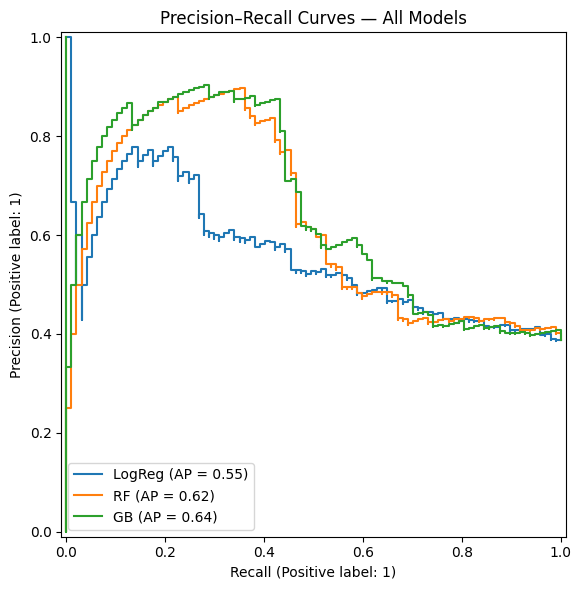

In [ ]:
# ROC curves in one subplot
plt.figure(figsize=(8, 6))
for name, gs in models.items():
    RocCurveDisplay.from_estimator(
        gs.best_estimator_, X_test, y_test, ax=plt.gca(), name=name
    )
plt.title("ROC Curves — All Models")
plt.tight_layout()
plt.show()

# PR curves in one subplot
plt.figure(figsize=(8, 6))
for name, gs in models.items():
    PrecisionRecallDisplay.from_estimator(
        gs.best_estimator_, X_test, y_test, ax=plt.gca(), name=name
    )
plt.title("Precision–Recall Curves — All Models")
plt.tight_layout()

The insights about the above chart are the followings:

Ranking (ROC AUC): GB 0.69 ≥ RF 0.68 > LogReg 0.65 → tree models rank buyers better than logistic regression.

Imbalance lens (PR AUC): GB 0.64, RF 0.62, LogReg 0.55 → both tree models provide noticeably higher precision for a given recall.

Practical use: Either GB (slight leader) or RF is a solid choice; LogReg is consistently weaker.

### Ensamble

The following block is aimed to use various models together to get the most accurate prediction on the model. 

- First tuned estimators are collected, and stored with the best pipeline developed previously

- The Ensamble is define with VotingClassifier (combines model probabilities ) and StackingClassifier (trains a LogisticRegression model on the predictions of the base models)

- Fit and  evaluation

- Try of each ensemble on (X_train, y_train), evaluation on (X_test, y_test) and collection of the metrics

- The reuslts are compared with single models and the winner is chosen

- Ensemble metrics are concatenated with the existing single‑model metrics test_df, sorted by test ROC AUC, and the selected model name is printed.

- Shows a ranked table of most influential features.

Model ensembling is the practice of combining predictions from multiple models to get a single, usually better, prediction.
The idea: different models make different errors; by aggregating them you reduce variance, often improve accuracy, and get more robust results.

In [44]:
# 1) Collect tuned base estimators (from your Grid/RandomizedSearchCV objects)
estimators = [(k, v.best_estimator_) for k, v in models.items()]

# 2) Build ensembles we can actually fit
can_soft_vote = all(hasattr(est, "predict_proba") for _, est in estimators)
ensembles = {
    "Voting": VotingClassifier(
        estimators=estimators, voting="soft" if can_soft_vote else "hard"
    ),
    "Stacking": StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000),
        # passthrough=True  # uncomment if you want meta-model to also see raw features
    ),
}

# 3) Fit + evaluate each ensemble in a tiny loop
ens_results, fitted_ensembles = [], {}
for name, est in ensembles.items():
    try:
        est.fit(X_train, y_train)
        ens_results.append(evaluate(name, est, X_test, y_test))
        fitted_ensembles[name] = est
    except Exception as e:
        warnings.warn(f"{name} failed: {e}")

ens_df = pd.DataFrame(ens_results)
if not ens_df.empty:
    print("Ensemble metrics:")
    display(ens_df)

# 4) Merge with single-model metrics & pick the winner by ROC AUC
combined = (
    pd.concat([test_df, ens_df], ignore_index=True)
    if not ens_df.empty
    else test_df.copy()
)
final_choice = combined.sort_values("test_roc_auc", ascending=False)["model"].iloc[0]
print("Final selected model:", final_choice)

# 5) Get the actual fitted winner (either a base model or an ensemble)
all_candidates = {
    **{k: v.best_estimator_ for k, v in models.items()},
    **fitted_ensembles,
}
final_model = all_candidates.get(final_choice)

# 6) (Optional) Permutation importance on the winner
if final_model is not None:
    r = permutation_importance(
        final_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
    )

    # Try to pull feature names from your pipeline's ColumnTransformer
    prep = (
        final_model.named_steps["prep"]
        if hasattr(final_model, "named_steps") and "prep" in final_model.named_steps
        else None
    )
    if prep is not None and hasattr(prep, "get_feature_names_out"):
        feat_names = prep.get_feature_names_out()
    else:
        feat_names = np.array([f"f{i}" for i in range(r.importances_mean.shape[0])])

    # Ensure feature names match importances length
    if len(feat_names) != len(r.importances_mean):
        feat_names = np.array([f"f{i}" for i in range(len(r.importances_mean))])

    imp = pd.DataFrame(
        {
            "feature": feat_names,
            "importance_mean": r.importances_mean,
            "importance_std": r.importances_std,
        }
    ).sort_values("importance_mean", ascending=False)
    print("Permutation importances:")
    display(imp.head(20))

Ensemble metrics:


,model,test_roc_auc,test_accuracy,test_f1,test_precision,test_recall,test_avg_precision
0,Voting,0.679907,0.388,0.559078,0.388,1.0,0.623188
1,Stacking,0.681187,0.388,0.559078,0.388,1.0,0.631924


Final selected model: GB
Permutation importances:


,feature,importance_mean,importance_std
3,f3,0.1292,0.024268
0,f0,0.0580,0.014339
4,f4,0.0524,0.012322
6,f6,0.0032,0.002400
1,f1,0.0024,0.001960
11,f11,0.0016,0.001960
2,f2,0.0008,0.002993
5,f5,0.0000,0.000000
10,f10,0.0000,0.000000
8,f8,-0.0008,0.001600


Ensembles didn’t beat GB.

Voting: ROC AUC 0.680, AP 0.623

Stacking: ROC AUC 0.681, AP 0.632

Earlier best base (GB): ROC AUC ~0.686, AP ~0.638 indeed the ensembles are about the same or slightly worse than GB, so selecting GB is reasonable.

### PDP Display

As the Annual Income represents one of most dependent variable for the Travel Insurance, the aim is so display it on the model.

1) Logistic Regression: pull coefficients for “AnnualIncome”

- Grabs the tuned Logistic Regression pipeline 

- Extract the coefficients from the LR classifiers and paired them with the features name

The result tells the direction (sign) and relative weight of any transformed columns derived from AnnualIncome 


2) Partial Dependence Plot (PDP) for AnnualIncome

- Looks for an AnnualIncome feature in your modeling table (AnnualIncome_num preferred, else AnnualIncome).

It shows the marginal effect of AnnualIncome on the model’s predicted probability of buying insurance, averaging over the distribution of other features.

What are the expected outcomes ?

Coefficients: “Is higher income associated with higher odds?” (sign) and roughly how strongly (magnitude, with the scaling caveat).

PDP: “How does predicted probability change across the income range?” (shape/monotonicity, thresholds, diminishing returns).

Logistic Regression — AnnualIncome-related coefficients (as ODDS RATIOS):


,feature,coef,odds_ratio
1,num__AnnualIncome,0.291379,1.338271
8,num__AnnualIncome_num,0.291379,1.338271


pyALE not installed; falling back to Partial Dependence (PDP).


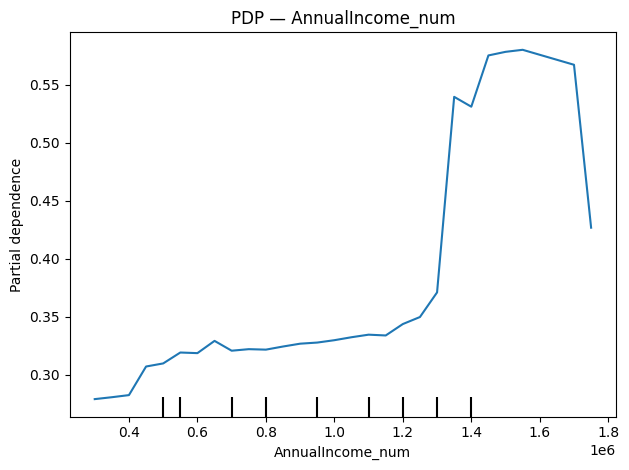

In [ ]:
if "LogReg" in models:
    pipe = models["LogReg"].best_estimator_  # Pipeline(prep -> clf)
    prep = pipe.named_steps.get("prep")
    clf = pipe.named_steps.get("clf")

    try:
        # Tries to get the post-transform feature names from the preprocessor (prep.get_feature_names_out()); if that’s not available, it falls back to dummy names f0…fN.
        if prep is not None and hasattr(prep, "get_feature_names_out"):
            feat_names = prep.get_feature_names_out()
        elif isinstance(X_train, pd.DataFrame):
            feat_names = np.array(X_train.columns)
        else:
            n_out = (
                prep.transform(X_train.iloc[:1]).shape[1]
                if prep is not None
                else clf.coef_.shape[1]
            )
            feat_names = np.array([f"f{i}" for i in range(n_out)])

        coefs = clf.coef_.ravel()
        coef_df = pd.DataFrame({"feature": feat_names, "coef": coefs})
        coef_df["odds_ratio"] = np.exp(coef_df["coef"])

        # Show only features stemming from AnnualIncome (case-insensitive)
        inc_mask = coef_df["feature"].str.contains("annualincome", case=False, na=False)
        inc_or = coef_df.loc[inc_mask].sort_values("odds_ratio", ascending=False)

        print(
            "Logistic Regression — AnnualIncome-related coefficients (as ODDS RATIOS):"
        )
        # Interpretation: OR > 1 increases odds of buying; OR < 1 decreases odds.
        display(inc_or)

    except Exception as e:
        print("Could not extract logistic coefficients/odds ratios:", e)

# ALE plot for AnnualIncome (falls back to PDP if pyALE not installed)
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

income_feat = (
    "AnnualIncome_num"
    if "AnnualIncome_num" in X_train.columns
    else ("AnnualIncome" if "AnnualIncome" in X_train.columns else None)
)

if income_feat is not None:
    try:
        # Prefer ALE (less biased than PDP when features are correlated)
        from pyALE import ale

        # Wrap model to return P(y=1)
        def proba1(X):
            return final_model.predict_proba(X)[:, 1]

        fig, ax = plt.subplots(figsize=(7, 5))
        _ = ale(
            X=X_test,  # DataFrame with the same columns as training
            model=proba1,  # callable returning probabilities for class 1
            feature=[income_feat],  # single feature list
            grid_size=20,
            include_CI=False,
            ax=ax,
        )
        ax.set_title(f"ALE — Effect of {income_feat} on P(TravelInsurance=1)")
        ax.set_ylabel("ALE (centered effect)")
        ax.set_xlabel(income_feat)
        plt.tight_layout()
        plt.show()

    except ImportError:
        print("pyALE not installed; falling back to Partial Dependence (PDP).")
        PartialDependenceDisplay.from_estimator(final_model, X_test, [income_feat])
        plt.title(f"PDP — {income_feat}")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("ALE computation failed, falling back to PDP. Reason:", e)
        try:
            PartialDependenceDisplay.from_estimator(final_model, X_test, [income_feat])
            plt.title(f"PDP — {income_feat}")
            plt.tight_layout()
            plt.show()
        except Exception as e2:
            print("PDP also failed:", e2)
else:
    print("AnnualIncome not in features; skipping ALE/PDP.")

Positive effect: higher income ⇒ higher predicted probability of buying.

Knee at ~1.3–1.4M: clear step-up in propensity (non-linear threshold).

Plateau ~1.5–1.6M: diminishing returns beyond this range.

Right-tail dip: likely noise from few samples (see sparse tick marks).

Consistent with LR: income has a positive effect (odds ratio ≈ 1.34 per scaled unit).


## Conclusions

We verified how among all the variables, the Annual Income is having a big impact on the likeness of buying or no a Travel Insurance, as well as the type of traveller (frequent or not-frequent).

Based on this conclusion, a model involving gradient-boosting ensamble was created, showing overall a good quality compared to other models. The missing accurancy and quality target may be due to inbalances data and incorrect threshold put in the learning model.

As conclusion, the target for this product should be frequent traveller, earning possibly more than 1.4 million Dirhams per year, following some potential strategies:

- offering all-inclusive packages, with Insurance included, for luxury travels (5-stars hotels, VIP events, ...)
- offering a special package for who is travelling often based on work
- offering discounts or cheaper Insurance packages to frequent flyers, in order to lower the dependece related to the Annual Income
